In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

session_df = pd.read_csv("../data/analysis_table/session_table.csv")

session_df.head()

,Unnamed: 0,user_id,user_session,session_start,session_end,total_events,view_count,cart_count,purchase_count,total_revenue,has_view,has_cart,has_purchase
0,0,43295513,9f49a167-1cb1-4918-8d47-1ccb1c4b4f39,2019-11-26 11:17:14+00:00,2019-11-26 11:17:14+00:00,1,1,0,0,0.0,1,0,0
1,1,49484535,0748511a-6ddf-4018-b093-8779cf863e4e,2019-11-22 15:30:22+00:00,2019-11-22 15:30:22+00:00,1,1,0,0,0.0,1,0,0
2,2,49484535,08d4b672-8592-4569-9bcf-94449ab2e471,2019-11-22 15:43:04+00:00,2019-11-22 15:43:04+00:00,1,1,0,0,0.0,1,0,0
3,3,49484535,0b564e29-57a2-48c2-bc93-7b35b96b7a84,2019-11-27 13:09:11+00:00,2019-11-27 13:09:11+00:00,1,1,0,0,0.0,1,0,0
4,4,49484535,16d460d5-d37e-4a4d-bb9c-3e9bb862dfe7,2019-11-20 17:08:37+00:00,2019-11-20 17:08:37+00:00,1,1,0,0,0.0,1,0,0


In [3]:
avg_session_conversion_rate = session_df['has_purchase'].mean()
print(f"Overall session conversion rate: {avg_session_conversion_rate:.2%}")

Overall session conversion rate: 5.51%


In [4]:
session_df['event_counts_bucket'] = pd.cut(
    session_df['total_events'],
    bins = [0, 1, 2, 3, 5, 10, 20, 50, 1000],
    labels = ['1', '2', '3', '4-5', '6-10', '11-20', '21-50', '50+']
)

session_engagement_analysis = (
    session_df.groupby('event_counts_bucket').agg(sessions = ('user_session', 'count'), conversion_rate = ('has_purchase','mean'))
    .reset_index()
    )

session_engagement_analysis['conversion_rate'] = session_engagement_analysis['conversion_rate'].round(4)

print(session_engagement_analysis)

  event_counts_bucket  sessions  conversion_rate
0                   1   1026053           0.0007
1                   2    433188           0.0122
2                   3    290497           0.0898
3                 4-5    353612           0.1240
4                6-10    372477           0.1162
5               11-20    208878           0.1105
6               21-50     87152           0.1114
7                 50+     11455           0.1277


/var/folders/j4/_7mlrdbn2_b0x18qdr4_qxr00000gn/T/ipykernel_30904/3998116197.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_df.groupby('event_counts_bucket').agg(sessions = ('user_session', 'count'), conversion_rate = ('has_purchase','mean'))


In [5]:
session_df['view_counts_bucket'] = pd.cut(
    session_df['view_count'],
    bins = [0, 1, 2, 3, 5, 10, 20, 50, 1000],
    labels = ['1', '2', '3', '4-5', '6-10', '11-20', '21-50', '50+']
)

view_analysis = (session_df.groupby('view_counts_bucket').agg(
        view_sessions = ('user_session', 'count'),
        conversion_rate = ('has_purchase','mean')
        ).reset_index()
        )

view_analysis['conversion_rate'] = view_analysis['conversion_rate'].round(4)

print(view_analysis)

  view_counts_bucket  view_sessions  conversion_rate
0                  1        1087234           0.0252
1                  2         466387           0.0732
2                  3         279799           0.0744
3                4-5         324734           0.0746
4               6-10         340366           0.0713
5              11-20         191515           0.0712
6              21-50          80748           0.0820
7                50+          10648           0.1045


/var/folders/j4/_7mlrdbn2_b0x18qdr4_qxr00000gn/T/ipykernel_30904/3912032489.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  view_analysis = (session_df.groupby('view_counts_bucket').agg(


In [6]:
# cart to purchase behavior
cart_sessions = session_df[session_df['has_cart'] == 1]

cart_to_purchase_rate = cart_sessions['has_purchase'].mean()
cart_abandon_rate = 1 - cart_to_purchase_rate

print(f"Cart → Purchase rate: {cart_to_purchase_rate:.2%}")
print(f"Cart abandonment rate: {cart_abandon_rate:.2%}")

Cart → Purchase rate: 36.91%
Cart abandonment rate: 63.09%


In [8]:
session_df['cart_counts_bucket'] = pd.cut(
    session_df['cart_count'],
    bins = [-1, 0, 1, 2, 3, 5, 10, 50],  # starting from -1 because we want to include those who didn't cart
    labels = ['0', '1', '2', '3', '4-5', '6-10', '10+']
)

cart_intensity = (session_df.groupby('cart_counts_bucket').agg(
        sessions = ('user_session','count'),
        conversion_rate = ('has_purchase','mean')
        ).reset_index()
        )

cart_intensity['conversion_rate'] = cart_intensity['conversion_rate'].round(4)
cart_intensity

/var/folders/j4/_7mlrdbn2_b0x18qdr4_qxr00000gn/T/ipykernel_30904/4105429.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cart_intensity = (session_df.groupby('cart_counts_bucket').agg(


,cart_counts_bucket,sessions,conversion_rate
0,0,2435003,0.0102
1,1,227936,0.3449
2,2,70075,0.4086
3,3,26029,0.4273
4,4-5,16444,0.4335
5,6-10,6525,0.4003
6,10+,1292,0.3498


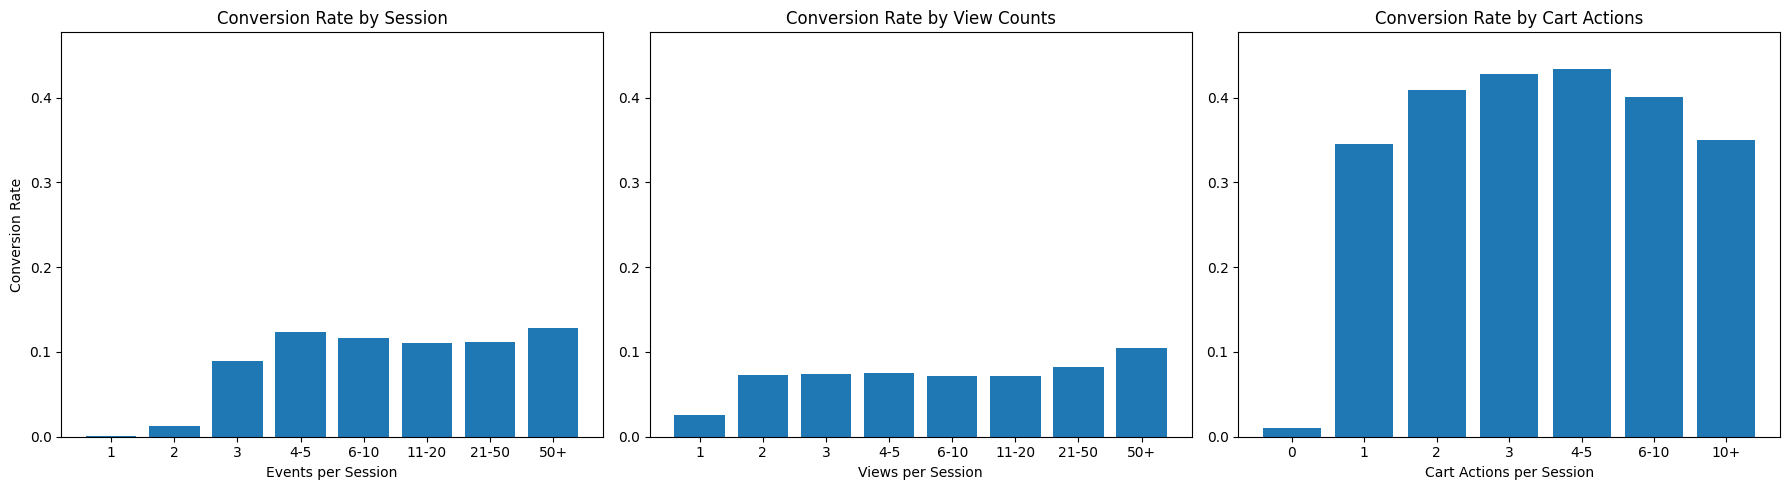

In [10]:
fig, axes = plt.subplots(1, 3, figsize = (18, 5))

y_max = max(session_engagement_analysis['conversion_rate'].max(), view_analysis['conversion_rate'].max(), cart_intensity['conversion_rate'].max()) * 1.1

# --- 1. Session Engagement ---
axes[0].bar(session_engagement_analysis['event_counts_bucket'], session_engagement_analysis['conversion_rate'])
axes[0].set_title("Conversion Rate by Session")
axes[0].set_xlabel("Events per Session")
axes[0].set_ylabel("Conversion Rate")
axes[0].set_ylim(0, y_max)

# --- 2. View Counts ---
axes[1].bar(view_analysis['view_counts_bucket'], view_analysis['conversion_rate'])
axes[1].set_title("Conversion Rate by View Counts")
axes[1].set_xlabel("Views per Session")
axes[1].set_ylim(0, y_max)

# --- 3. Cart Actions ---
axes[2].bar(cart_intensity['cart_counts_bucket'], cart_intensity['conversion_rate'])
axes[2].set_title("Conversion Rate by Cart Actions")
axes[2].set_xlabel("Cart Actions per Session")
axes[2].set_ylim(0, y_max)

plt.tight_layout()
plt.show()

## Session-level Conversion Driver Summary

This analysis explores how session engagement and user behavior influence purchase conversion.

### Key Findings

- Conversion rate increases consistently with higher session engagement. Sessions with more events are significantly more likely to convert.
- Sessions with more views show higher conversion rate.
- Cart actions are the strongest predictor of conversion.
